In [ ]:
!pip install kaggle --quiet

import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_caec5d3ecc6a6fbbeaba340e14173ed0'

In [ ]:
!kaggle competitions download -c aptos2019-blindness-detection

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [ ]:
!pip install --upgrade kaggle --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.5 MB/s eta 0:00:00


In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = 'amnashwaseem'
os.environ['KAGGLE_KEY'] = '1e4fb62bd0a6137e7bcb29fca186b124'

In [ ]:
!kaggle competitions download -c aptos2019-blindness-detection

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [ ]:
!kaggle competitions download -c aptos2019-blindness-detection

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [ ]:
!kaggle datasets download -d mariaherrerot/aptos2019

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [01:19<00:00, 109MB/s]



In [ ]:
!unzip -q aptos2019.zip -d aptos2019_data

In [ ]:
!ls aptos2019_data

test.csv  test_images  train_1.csv  train_images  valid.csv  val_images


In [ ]:
import pandas as pd

train_df = pd.read_csv('aptos2019_data/train_1.csv')
val_df = pd.read_csv('aptos2019_data/valid.csv')
test_df = pd.read_csv('aptos2019_data/test.csv')

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain columns:", train_df.columns.tolist())
print("\nTrain head:")
train_df.head()

Train shape: (2930, 2)
Val shape: (366, 2)
Test shape: (366, 2)

Train columns: ['id_code', 'diagnosis']

Train head:


,id_code,diagnosis
0,1ae8c165fd53,2
1,1b329a127307,1
2,1b32e1d775ea,4
3,1b3647865779,0
4,1b398c0494d1,0


Train set distribution:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64


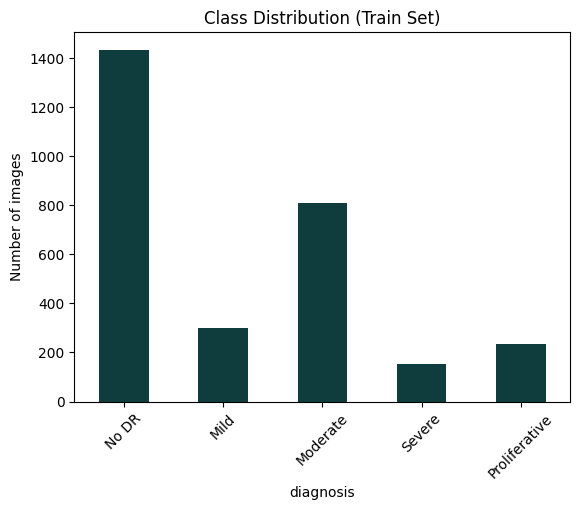

In [ ]:
import matplotlib.pyplot as plt

labels = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative'}

print("Train set distribution:")
print(train_df['diagnosis'].value_counts().sort_index())

train_df['diagnosis'].value_counts().sort_index().plot(kind='bar', color='#0F3D3E')
plt.xticks(range(5), [labels[i] for i in range(5)], rotation=45)
plt.title('Class Distribution (Train Set)')
plt.ylabel('Number of images')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'aptos2019_data/train_images/1b3647865779.png'

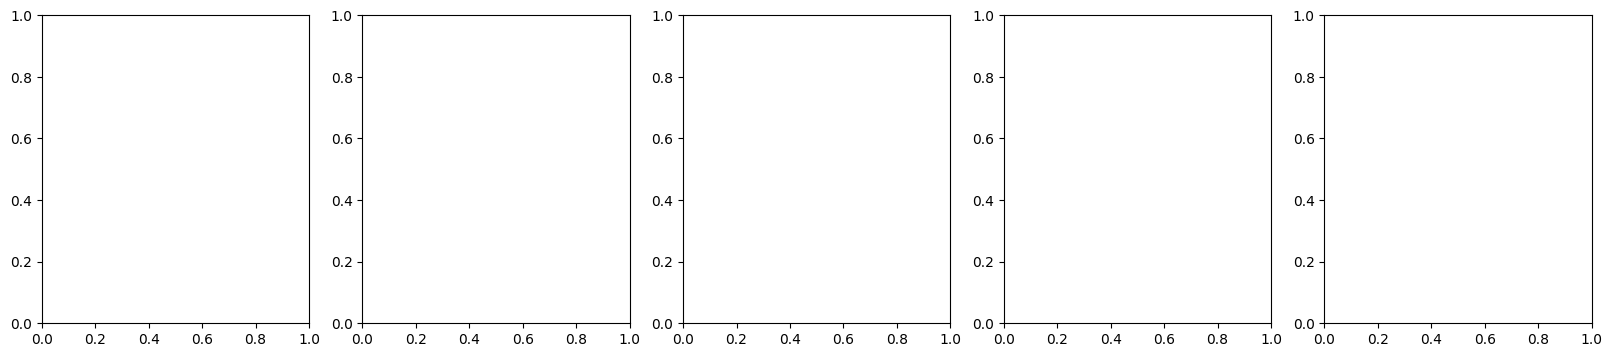

In [ ]:
import matplotlib.image as mpimg
import os

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for grade in range(5):
    sample_id = train_df[train_df['diagnosis'] == grade]['id_code'].iloc[0]
    img_path = f'aptos2019_data/train_images/{sample_id}.png'
    img = mpimg.imread(img_path)
    axes[grade].imshow(img)
    axes[grade].set_title(f'{labels[grade]} (grade {grade})')
    axes[grade].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
print(os.listdir('aptos2019_data/train_images')[:5])

['train_images']


In [ ]:
import os
print(os.listdir('aptos2019_data/train_images/train_images')[:5])

['4528fbbd43a3.png', '259d30f693b6.png', '7a39c91416e2.png', 'db690e2d02f8.png', 'b4b04d81acbb.png']


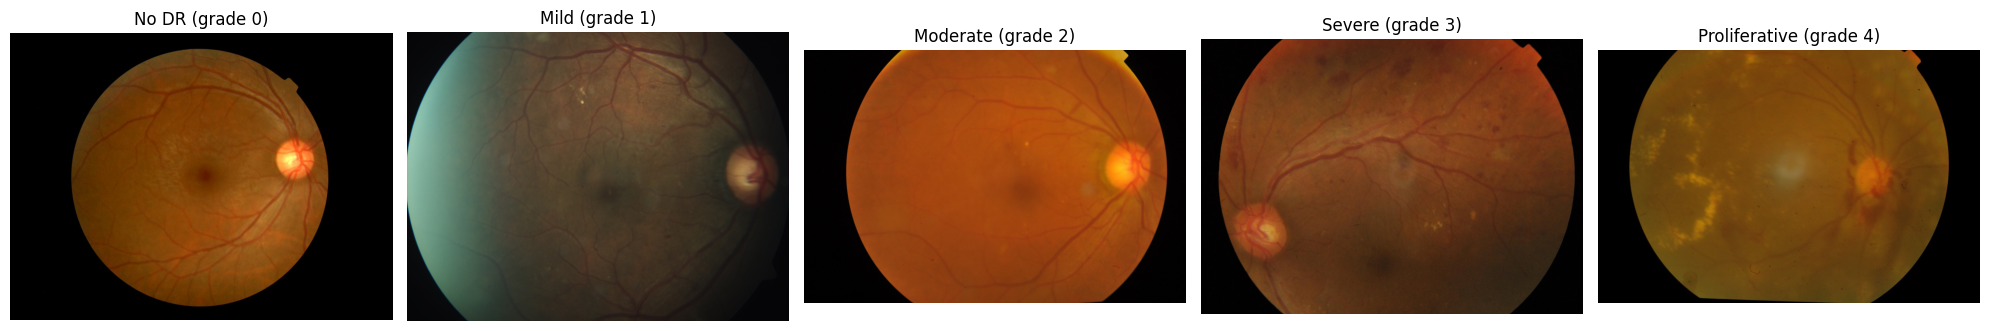

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for grade in range(5):
    sample_id = train_df[train_df['diagnosis'] == grade]['id_code'].iloc[0]
    img_path = f'aptos2019_data/train_images/train_images/{sample_id}.png'
    img = mpimg.imread(img_path)
    axes[grade].imshow(img)
    axes[grade].set_title(f'{labels[grade]} (grade {grade})')
    axes[grade].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image

sizes = []
for img_name in os.listdir('aptos2019_data/train_images/train_images')[:20]:
    img_path = f'aptos2019_data/train_images/train_images/{img_name}'
    img = Image.open(img_path)
    sizes.append(img.size)

print("Sample image sizes:", sizes[:10])
print("Unique sizes:", set(sizes))

Sample image sizes: [(1050, 1050), (1050, 1050), (1050, 1050), (1050, 1050), (1050, 1050), (1050, 1050), (2588, 1958), (2588, 1958), (1050, 1050), (2416, 1736)]
Unique sizes: {(2416, 1736), (2048, 1536), (2588, 1958), (1050, 1050), (819, 614)}


In [ ]:
import cv2
import numpy as np

def crop_image_from_gray(img, tol=7):
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol
        check_shape = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0]
        if check_shape == 0:
            return img
        else:
            img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
            return np.stack([img1, img2, img3], axis=-1)

def ben_graham_preprocess(image_path, output_size=224, sigma_x=10):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_image_from_gray(img)
    img = cv2.resize(img, (output_size, output_size))
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), sigma_x), -4, 128)
    return img

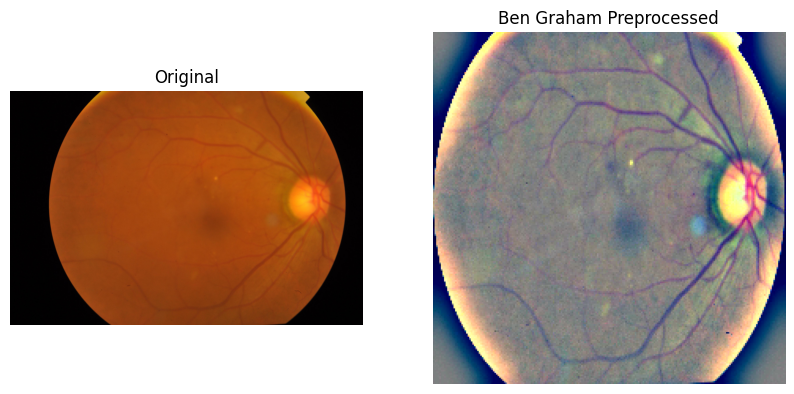

In [ ]:
sample_id = train_df['id_code'].iloc[0]
img_path = f'aptos2019_data/train_images/train_images/{sample_id}.png'

original = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
processed = ben_graham_preprocess(img_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(processed)
axes[1].set_title('Ben Graham Preprocessed')
axes[1].axis('off')
plt.show()

In [ ]:
import os
from tqdm import tqdm

def process_and_save(df, source_folder, dest_folder):
    os.makedirs(dest_folder, exist_ok=True)
    for img_id in tqdm(df['id_code']):
        src_path = f'{source_folder}/{img_id}.png'
        dst_path = f'{dest_folder}/{img_id}.png'
        try:
            processed = ben_graham_preprocess(src_path)
            processed_bgr = cv2.cvtColor(processed, cv2.COLOR_RGB2BGR)
            cv2.imwrite(dst_path, processed_bgr)
        except Exception as e:
            print(f"Error processing {img_id}: {e}")

# Train images process karein
process_and_save(train_df, 'aptos2019_data/train_images/train_images', 'processed/train')

# Val images process karein
process_and_save(val_df, 'aptos2019_data/val_images/val_images', 'processed/val')

100%|██████████| 366/366 [01:09<00:00,  5.26it/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/RetinaScan_Data
!cp -r processed /content/drive/MyDrive/RetinaScan_Data/

In [6]:
!pip install timm --quiet

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install kaggle timm --quiet

In [5]:
import os
os.environ['KAGGLE_USERNAME'] = 'amnashwaseem'
os.environ['KAGGLE_KEY'] = '1e4fb62bd0a6137e7bcb29fca186b124'

!kaggle datasets download -d mariaherrerot/aptos2019
!unzip -q aptos2019.zip -d aptos2019_data

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
aptos2019.zip: Skipping, found more recently modified local copy (use --force to force download)
replace aptos2019_data/test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [7]:
!unzip -o -q aptos2019.zip -d aptos2019_data

In [5]:
import torch
print(torch.cuda.is_available())

True


In [8]:
import pandas as pd

train_df = pd.read_csv('aptos2019_data/train_1.csv')
val_df = pd.read_csv('aptos2019_data/valid.csv')

print("Train:", train_df.shape)
print("Val:", val_df.shape)

Train: (2930, 2)
Val: (366, 2)


In [9]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [10]:
!pip install timm --quiet

In [11]:
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

class RetinaDataset(Dataset):
    def __init__(self, df, img_folder, transform=None):
        self.df = df
        self.img_folder = img_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['id_code']
        label = self.df.iloc[idx]['diagnosis']
        img_path = f'{self.img_folder}/{img_id}.png'
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [12]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [13]:
train_dataset = RetinaDataset(train_df, '/content/drive/MyDrive/RetinaScan_Data/processed/train', transform=train_transform)
val_dataset = RetinaDataset(val_df, '/content/drive/MyDrive/RetinaScan_Data/processed/val', transform=val_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 92
Val batches: 12


In [14]:
import timm
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=5)
model = model.to(device)

print("Model loaded on:", device)

Model loaded on: cuda


In [15]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [16]:
from sklearn.metrics import cohen_kappa_score

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return total_loss / len(loader), kappa

In [17]:
num_epochs = 10
best_kappa = 0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_kappa = validate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val QWK: {val_kappa:.4f}")

    if val_kappa > best_kappa:
        best_kappa = val_kappa
        torch.save(model.state_dict(), '/content/drive/MyDrive/RetinaScan_Data/best_model.pth')
        print("  → New best model saved!")

Epoch 1/10 - Train Loss: 1.2597 - Val Loss: 0.8735 - Val QWK: 0.7684
  → New best model saved!
Epoch 2/10 - Train Loss: 0.6455 - Val Loss: 0.7100 - Val QWK: 0.8486
  → New best model saved!
Epoch 3/10 - Train Loss: 0.4734 - Val Loss: 0.6986 - Val QWK: 0.8443
Epoch 4/10 - Train Loss: 0.3974 - Val Loss: 0.6277 - Val QWK: 0.8593
  → New best model saved!
Epoch 5/10 - Train Loss: 0.3165 - Val Loss: 0.5757 - Val QWK: 0.8637
  → New best model saved!
Epoch 6/10 - Train Loss: 0.2626 - Val Loss: 0.5666 - Val QWK: 0.8549
Epoch 7/10 - Train Loss: 0.2198 - Val Loss: 0.6536 - Val QWK: 0.8787
  → New best model saved!
Epoch 8/10 - Train Loss: 0.1928 - Val Loss: 0.7453 - Val QWK: 0.8705
Epoch 9/10 - Train Loss: 0.1550 - Val Loss: 0.7074 - Val QWK: 0.8454
Epoch 10/10 - Train Loss: 0.1356 - Val Loss: 0.7829 - Val QWK: 0.8581


In [18]:
model.load_state_dict(torch.load('/content/drive/MyDrive/RetinaScan_Data/best_model.pth'))
model.eval()
print("Best model loaded successfully")

Best model loaded successfully


In [19]:
!pip install grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [23]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np

target_layer = [model.conv_head]

def generate_gradcam(model, image_tensor, original_image_np, target_layer, target_class=None):
    cam = GradCAM(model=model, target_layers=target_layer)
    input_tensor = image_tensor.unsqueeze(0).to(device)

    if target_class is not None:
        targets = [ClassifierOutputTarget(target_class)]
    else:
        targets = None

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]
    visualization = show_cam_on_image(original_image_np, grayscale_cam, use_rgb=True)
    return visualization

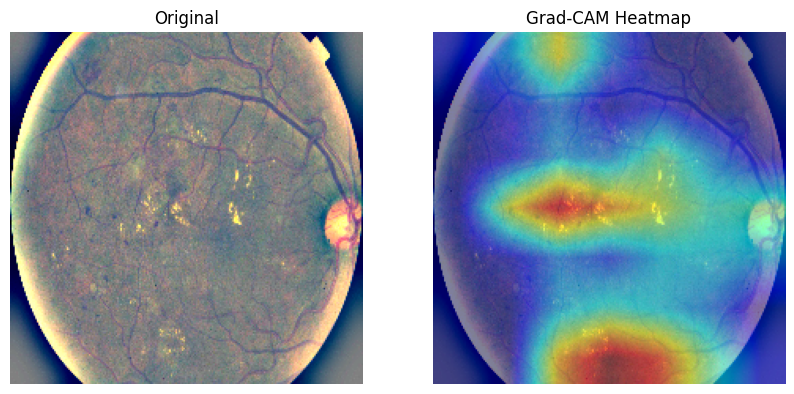

In [24]:
import matplotlib.pyplot as plt

sample_id = val_df['id_code'].iloc[0]
img_path = f'/content/drive/MyDrive/RetinaScan_Data/processed/val/{sample_id}.png'

image = Image.open(img_path).convert('RGB')
image_np = np.array(image).astype(np.float32) / 255.0
image_tensor = val_transform(image)

heatmap = generate_gradcam(model, image_tensor, image_np, target_layer)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_np)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(heatmap)
axes[1].set_title('Grad-CAM Heatmap')
axes[1].axis('off')
plt.show()

In [25]:
import cv2

def check_blur(image_path, threshold=100):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    is_blurry = laplacian_var < threshold
    return is_blurry, laplacian_var

In [26]:
def check_brightness(image_path, dark_threshold=40, bright_threshold=220):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mean_brightness = gray.mean()
    is_too_dark = mean_brightness < dark_threshold
    is_too_bright = mean_brightness > bright_threshold
    return is_too_dark, is_too_bright, mean_brightness

In [27]:
def quality_check(image_path):
    is_blurry, blur_score = check_blur(image_path)
    is_too_dark, is_too_bright, brightness = check_brightness(image_path)

    issues = []
    if is_blurry:
        issues.append(f"Image is too blurry (score: {blur_score:.1f})")
    if is_too_dark:
        issues.append(f"Image is too dark (brightness: {brightness:.1f})")
    if is_too_bright:
        issues.append(f"Image is too bright (brightness: {brightness:.1f})")

    passed = len(issues) == 0
    return passed, issues

In [28]:
sample_id = val_df['id_code'].iloc[0]
img_path = f'/content/drive/MyDrive/RetinaScan_Data/processed/val/{sample_id}.png'

passed, issues = quality_check(img_path)
print("Passed:", passed)
print("Issues:", issues if issues else "None")

Passed: True
Issues: None


In [29]:
# Original image ko artificially blur karke test karein
img = cv2.imread(img_path)
blurred_img = cv2.GaussianBlur(img, (25, 25), 0)
cv2.imwrite('test_blurry.png', blurred_img)

passed, issues = quality_check('test_blurry.png')
print("Passed:", passed)
print("Issues:", issues)

Passed: False
Issues: ['Image is too blurry (score: 3.2)']


In [30]:
from google.colab import files
files.download('/content/drive/MyDrive/RetinaScan_Data/best_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>